## **IMPORT LIBRARY**

In [639]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Model
import lightgbm as lgb

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

## **SETUP FILE**

In [640]:
df = pd.read_csv("dataset/train.csv")
dft = pd.read_csv("dataset/test.csv")
baris, kolom = df.shape
print(f'Baris: {baris}, Kolom: {kolom}')
target = 'property_organic_content'
df.head()

Baris: 11210, Kolom: 52


,sample_id,source_id,has_band_A_spectrum,has_band_B_spectrum,sampling_strategy,sampling_depth_cm,geo_zone_macro,geo_zone_micro,geo_zone_meso,land_cover_type,...,spectral_band_B_PC_6,spectral_band_B_PC_7,spectral_band_B_PC_8,spectral_band_B_PC_9,spectral_band_B_PC_10,spectral_band_B_PC_11,spectral_band_B_PC_12,spectral_band_B_PC_13,spectral_band_B_PC_14,spectral_band_B_PC_15
0,train_00001,Source_01,YES,NO,Auger,0-20,SE,Unknown,State_01,Seasonal Semideciduous Forest,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,train_00002,Source_10,YES,NO,Auger,0-20,MW,Loc_011,State_10,Savannah,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,train_00003,Source_04,YES,NO,Auger,0-20,S,Loc_001,State_06,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,train_00004,Source_02,YES,NO,Auger,0-20,N,Unknown,State_07,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,train_00005,Source_04,YES,NO,Auger,0-20,S,Loc_001,State_06,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **HANDLE MISSING VALUES**

In [641]:
missing_count = df.isnull().sum()
missing_percentage = df.isnull().mean() * 100

missing_df = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percentage': missing_percentage
})

missing_df = missing_df[missing_df['missing_count'] > 0]
print(missing_df.sort_values(by='missing_percentage', ascending=False))

                          missing_count  missing_percentage
cation_Na                         10808           96.413916
spectral_band_B_PC_7               9516           84.888492
spectral_band_B_PC_5               9516           84.888492
spectral_band_B_PC_6               9516           84.888492
spectral_band_B_PC_4               9516           84.888492
spectral_band_B_PC_3               9516           84.888492
spectral_band_B_PC_2               9516           84.888492
spectral_band_B_PC_1               9516           84.888492
spectral_band_B_PC_12              9516           84.888492
spectral_band_B_PC_9               9516           84.888492
spectral_band_B_PC_10              9516           84.888492
spectral_band_B_PC_11              9516           84.888492
spectral_band_B_PC_14              9516           84.888492
spectral_band_B_PC_13              9516           84.888492
spectral_band_B_PC_15              9516           84.888492
spectral_band_B_PC_8               9516 

- cation Na hilang 96.4 % --> Drop aja
- spectral b rata hilang 84 % --> lihat isinya dulu
- latitude, longitude hilang 74% ++ --> impute?
- property_acidity_index ilang 74% ++ juga --> impute?

### **Drop cation Na**

In [642]:
df = df.drop(columns= 'cation_Na')
dft = dft.drop(columns= 'cation_Na')

print('cation_Na ilang')

cation_Na ilang


### **EDA Spectral B**

In [643]:
spectral_b_cols = []
for i in range(1,16):
    spektral = f'spectral_band_B_PC_{i}'
    spectral_b_cols.append(spektral)

spectral_b_cols_df = df[spectral_b_cols]

apakah saat salah satu spectral band b kosong, maka semua ikut kosong?

In [644]:
for i in range(1,16):
    ratakosong = df[spectral_b_cols].isnull().all(axis=1).equals(df[f'spectral_band_B_PC_{i}'].isnull())
    print(i, ratakosong)

1 True
2 True
3 True
4 True
5 True
6 True
7 True
8 True
9 True
10 True
11 True
12 True
13 True
14 True
15 True


True, berarti semua kolom missing barengan. artinya,
- salah satu data spectral b ga ada, makasemua data spectral b ga ada
- satu sumber (source_id) gapunya data spectral b

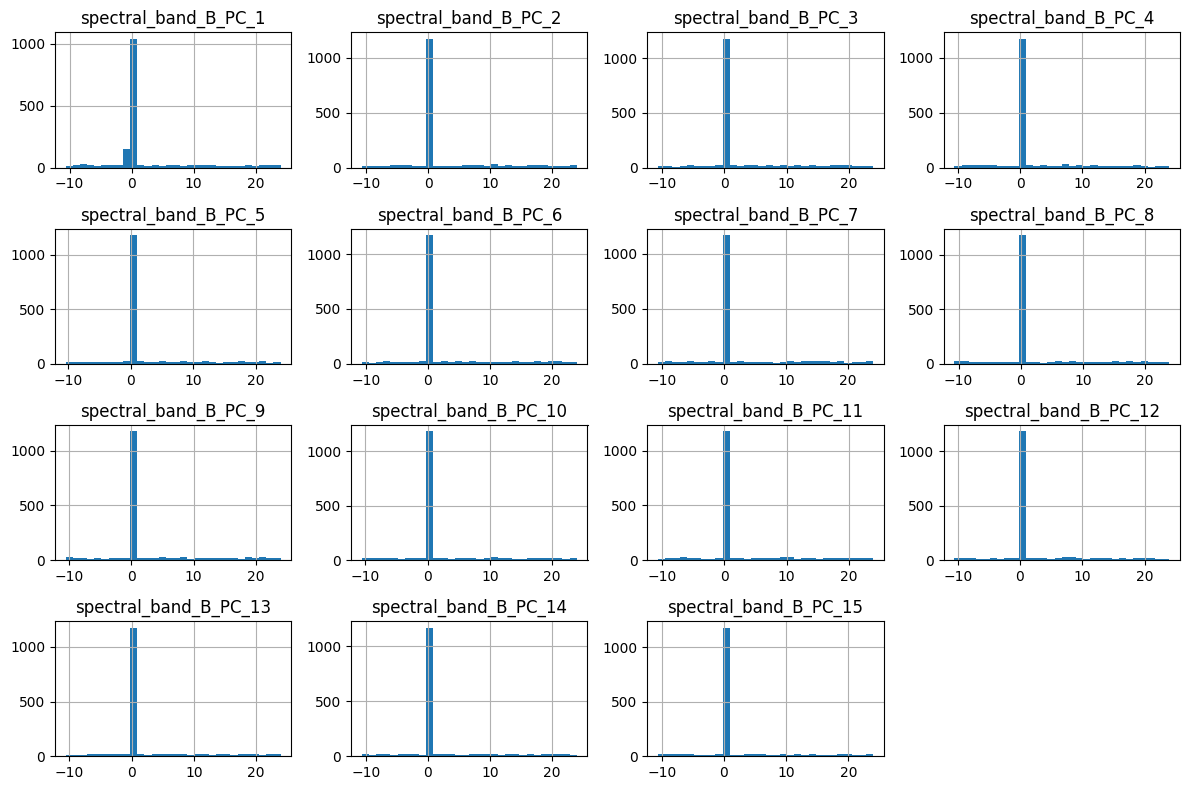

In [645]:
spectral_b_cols_df.dropna().hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

walaupun disitu dominan 0, tapi data yang hilang juga banyak (84%). maka ada 2 opsi, 
- biarin NaN dan tambahin flag aja
- flag + impute

coba2 aja

In [646]:
#FLAG
df['spectral_missing'] = df[spectral_b_cols].isna().all(axis=1).astype(int)
dft['spectral_missing'] = dft[spectral_b_cols].isna().all(axis=1).astype(int)

#IMPUTE
for col in spectral_b_cols:
    df[col] = df[col].fillna(df[col].median())
    dft[col] = dft[col].fillna(df[col].median())

### **EDA Latitude, Longitude**

In [647]:
#Flag
df['geo_missing'] = df[['latitude', 'longitude']].isna().all(axis=1).astype(int)
dft['geo_missing'] = dft[['latitude', 'longitude']].isna().all(axis=1).astype(int)

df.groupby('geo_missing')[target].mean()

geo_missing
0    34.586032
1    34.022336
Name: property_organic_content, dtype: float64

### **EDA keasaman tanah**

In [648]:
df.groupby('parent_rock_type')['property_acidity_index'].agg(['count', 'size'])
df.groupby('parent_rock_type')['property_acidity_index'].agg(
    total='size',
    filled='count'
).assign(
    fill_rate=lambda x: x['filled'] / x['total']
)

dft.groupby('parent_rock_type')['property_acidity_index'].agg(['count', 'size'])
dft.groupby('parent_rock_type')['property_acidity_index'].agg(
    total='size',
    filled='count'
).assign(
    fill_rate=lambda x: x['filled'] / x['total']
)

,total,filled,fill_rate
parent_rock_type,,,
Igneous Rock,1280,424,0.331250
Metamorphic Rock,122,17,0.139344
Sedimentary Rock,857,213,0.248541
Unknown,411,47,0.114355


Bisa dilihat bahwa untuk satu tipe batu yang sama, tidak selalu memiliki data property_acidity_index. Maka, Coba
1. kasih flag + impute median groupby tipe batu induk
2. kasih flag aja

In [649]:
#Flag
df['acidity_missing'] = df['property_acidity_index'].isna().astype(int)
dft['acidity_missing'] = dft['property_acidity_index'].isna().astype(int)

#Impute
df['property_acidity_index'] = df.groupby('parent_rock_type')['property_acidity_index']\
    .transform(lambda x: x.fillna(x.median()))
dft['property_acidity_index'] = dft.groupby('parent_rock_type')['property_acidity_index']\
    .transform(lambda x: x.fillna(x.median()))

### **EDA Ca, Mg, dan exc**

In [ ]:
# df['cation_Ca'] = df.groupby(['parent_rock_type'])['cation_Ca']\
#                     .transform(lambda x: x.fillna(x.median()))
# df['cation_Mg'] = df.groupby(['parent_rock_type'])['cation_Mg']\
#                     .transform(lambda x: x.fillna(x.median()))
# df['cation_exchange_capacity'] = df.groupby(['parent_rock_type'])['cation_exchange_capacity']\
#                     .transform(lambda x: x.fillna(x.median()))

# dft['cation_Ca'] = dft.groupby(['parent_rock_type'])['cation_Ca']\
#                     .transform(lambda x: x.fillna(x.median()))
# dft['cation_Mg'] = dft.groupby(['parent_rock_type'])['cation_Mg']\
#                     .transform(lambda x: x.fillna(x.median()))
# dft['cation_exchange_capacity'] = dft.groupby(['parent_rock_type'])['cation_exchange_capacity']\
#                     .transform(lambda x: x.fillna(x.median()))

### **Tambahan : Flag buat biome, parent rock type, land cover type**

In [ ]:
df['rock_missing'] = (df['parent_rock_type'] == 'Unknown').astype(int)
df['biome_missing'] = (df['biome'] == 'Unknown').astype(int)
df['land_missing'] = (df['land_cover_type'] == 'Unknown').astype(int)

dft['rock_missing'] = (dft['parent_rock_type'] == 'Unknown').astype(int)
dft['biome_missing'] = (dft['biome'] == 'Unknown').astype(int)
dft['land_missing'] = (dft['land_cover_type'] == 'Unknown').astype(int)

### **Cek Ulang missing Value**

In [652]:
missing_count = df.isnull().sum()
missing_percentage = df.isnull().mean() * 100

missing_df = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percentage': missing_percentage
})

missing_df = missing_df[missing_df['missing_count'] > 0]
print(missing_df.sort_values(by='missing_percentage', ascending=False))

                          missing_count  missing_percentage
longitude                          8820           78.679750
latitude                           8820           78.679750
property_particle_fine              767            6.842105
property_particle_coarse            752            6.708296


## **TRAIN**

In [653]:
cat_cols = df.select_dtypes(exclude='number').columns
df[cat_cols] = df[cat_cols].astype('category')
dft[cat_cols] = dft[cat_cols].astype('category')
df.dtypes

sample_id                   category
source_id                   category
has_band_A_spectrum         category
has_band_B_spectrum         category
sampling_strategy           category
sampling_depth_cm           category
geo_zone_macro              category
geo_zone_micro              category
geo_zone_meso               category
land_cover_type             category
biome                       category
parent_rock_type            category
property_particle_coarse     float64
property_particle_fine       float64
property_organic_content     float64
property_acidity_index       float64
cation_Ca                    float64
cation_Mg                    float64
cation_exchange_capacity     float64
latitude                     float64
longitude                    float64
spectral_band_A_PC_1         float64
spectral_band_A_PC_2         float64
spectral_band_A_PC_3         float64
spectral_band_A_PC_4         float64
spectral_band_A_PC_5         float64
spectral_band_A_PC_6         float64
s

In [654]:
X = df.drop(columns = target)
Xt = dft
y = df[target]
X.head()

,sample_id,source_id,has_band_A_spectrum,has_band_B_spectrum,sampling_strategy,sampling_depth_cm,geo_zone_macro,geo_zone_micro,geo_zone_meso,land_cover_type,...,spectral_band_B_PC_15,spectral_missing,geo_missing,acidity_missing,rock_missing,biome_missing,land_missing,Mg_missing,Ca_missing,exc_missing
0,train_00001,Source_01,YES,NO,Auger,0-20,SE,Unknown,State_01,Seasonal Semideciduous Forest,...,0.000902,1,1,1,0,0,0,0,0,0
1,train_00002,Source_10,YES,NO,Auger,0-20,MW,Loc_011,State_10,Savannah,...,0.000902,1,0,0,0,0,0,0,0,0
2,train_00003,Source_04,YES,NO,Auger,0-20,S,Loc_001,State_06,Unknown,...,0.000902,1,1,1,1,1,1,0,0,0
3,train_00004,Source_02,YES,NO,Auger,0-20,N,Unknown,State_07,Unknown,...,0.000902,1,1,0,0,0,1,0,0,0
4,train_00005,Source_04,YES,NO,Auger,0-20,S,Loc_001,State_06,Unknown,...,0.000902,1,1,1,1,1,1,0,0,0


In [655]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_rmse = []
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'verbose': -1,
    'random_state': 42
}

oof_pred = np.zeros(len(X))
test_pred = np.zeros(len(Xt))

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"Fold {fold+1}")
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val)

    model = lgb.train(
        params,
        train_data,
        num_boost_round=1000,
        valid_sets=[train_data, val_data],
        valid_names=['train', 'valid'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(period=100)
        ]
    )
    oof_pred[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
    test_pred += model.predict(Xt) / kf.n_splits
    rmse = np.sqrt(mean_squared_error(y_val, oof_pred[val_idx]))
    fold_rmse.append(rmse)

np.mean(fold_rmse)

Fold 1
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 9.05908	valid's rmse: 11.4719
[200]	train's rmse: 7.4518	valid's rmse: 11.2091
[300]	train's rmse: 6.49891	valid's rmse: 11.0748
[400]	train's rmse: 5.81562	valid's rmse: 11.0126
[500]	train's rmse: 5.23435	valid's rmse: 10.9779
Early stopping, best iteration is:
[519]	train's rmse: 5.1242	valid's rmse: 10.9683
Fold 2
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 9.12974	valid's rmse: 11.5312
[200]	train's rmse: 7.55597	valid's rmse: 11.2666
[300]	train's rmse: 6.62029	valid's rmse: 11.1998
[400]	train's rmse: 5.90023	valid's rmse: 11.1402
[500]	train's rmse: 5.30763	valid's rmse: 11.1253
[600]	train's rmse: 4.80403	valid's rmse: 11.1104
[700]	train's rmse: 4.38881	valid's rmse: 11.0742
Early stopping, best iteration is:
[716]	train's rmse: 4.31872	valid's rmse: 11.0705
Fold 3
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 9.13395	

np.float64(11.475772498564828)

In [656]:
rmse = np.sqrt(mean_squared_error(y, oof_pred))
print("OOF RMSE:", rmse)

OOF RMSE: 11.49403689381429


- awal = 11.436939660985386
- awal (no impute band b) = 11.485621218029852
- awal + imputasi multigroup = 11.50559923642648
- with imputasi Ca, Mg, exc + multigroup = 11.562517555998975
- with imputasi Ca, Mg, exc = 11.49403689381429

### **FEATURE IMPORTANCE**

In [657]:
importances = model.feature_importance(importance_type='gain')

feature_names = model.feature_name()

for name, val in zip(feature_names, importances):
    print(f"{name}: {val}")

sample_id: 0.0
source_id: 12634932.02204609
has_band_A_spectrum: 0.0
has_band_B_spectrum: 3345.122947692871
sampling_strategy: 369010.6033706665
sampling_depth_cm: 0.0
geo_zone_macro: 207402.59036636353
geo_zone_micro: 1227196.0216178894
geo_zone_meso: 1351299.304824829
land_cover_type: 285108.13971328735
biome: 50259.68460083008
parent_rock_type: 5571.148468017578
property_particle_coarse: 4520644.839879036
property_particle_fine: 7020711.428809166
property_acidity_index: 126161.46093940735
cation_Ca: 1131275.3163366318
cation_Mg: 1034439.4955101013
cation_exchange_capacity: 3829775.019575119
latitude: 65304.892793655396
longitude: 64755.85056114197
spectral_band_A_PC_1: 968658.3463687897
spectral_band_A_PC_2: 1085553.1900405884
spectral_band_A_PC_3: 1144039.874469757
spectral_band_A_PC_4: 465847.29481220245
spectral_band_A_PC_5: 1606897.018465042
spectral_band_A_PC_6: 674248.5839920044
spectral_band_A_PC_7: 714628.5097742081
spectral_band_A_PC_8: 450487.65201854706
spectral_band_A_PC

In [658]:
# submission
submission = pd.DataFrame({
    'sample_id': dft['sample_id'],
    'property_organic_content': test_pred
})

submission.to_csv('test3.csv', index=False)